# 1. Data  Dimensionality Reduction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
df = pd.read_csv('train.csv')
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
13620,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


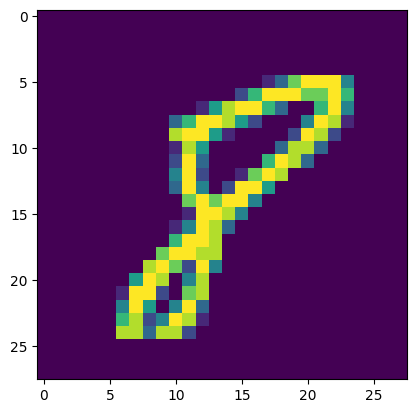

In [4]:
plt.imshow(df.iloc[18306,1:].values.reshape(28,28))

# Using KNN Manually with all features

In [5]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
X_train.shape

(33600, 784)

In [8]:
from sklearn.neighbors import KNeighborsClassifier

In [9]:
knn = KNeighborsClassifier()

In [10]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [11]:
import time
start = time.time()
y_pred = knn.predict(X_test)
print(time.time()-start)

15.027854442596436


In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

# Using PCA

###Step1. Scaling or Mean Centering

In [13]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [14]:
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

### Step2. Applying PCA

In [15]:
from sklearn.decomposition import PCA
pca = PCA(n_components=100)

In [16]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [17]:
X_train_trf.shape

(33600, 100)

In [18]:
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [19]:
y_pred_trf = knn.predict(X_test_trf)

In [20]:
accuracy_score(y_test,y_pred_trf)

0.9544047619047619

In [26]:
for i in range(1,785):
  pca = PCA(n_components=i)
  X_train_trf = pca.fit_transform(X_train)
  X_test_trf = pca.transform(X_test)
  knn.fit(X_train_trf,y_train)
  y_pred_trf = knn.predict(X_test_trf)
  print(i,"->",accuracy_score(y_test,y_pred_trf))
  if accuracy_score(y_test,y_pred_trf)>=0.955 :
     break

1 -> 0.2580952380952381
2 -> 0.3236904761904762
3 -> 0.5104761904761905
4 -> 0.6663095238095238
5 -> 0.7378571428571429
6 -> 0.8227380952380953
7 -> 0.8436904761904762
8 -> 0.8721428571428571
9 -> 0.886547619047619
10 -> 0.9055952380952381
11 -> 0.9116666666666666
12 -> 0.9184523809523809
13 -> 0.9276190476190476
14 -> 0.9351190476190476
15 -> 0.9384523809523809
16 -> 0.9379761904761905
17 -> 0.9407142857142857
18 -> 0.94
19 -> 0.9425
20 -> 0.9442857142857143
21 -> 0.9438095238095238
22 -> 0.9441666666666667
23 -> 0.9442857142857143
24 -> 0.9457142857142857
25 -> 0.9484523809523809
26 -> 0.9479761904761905
27 -> 0.9478571428571428
28 -> 0.9471428571428572
29 -> 0.949047619047619
30 -> 0.9491666666666667
31 -> 0.9507142857142857
32 -> 0.9513095238095238
33 -> 0.95
34 -> 0.9504761904761905
35 -> 0.950952380952381
36 -> 0.9519047619047619
37 -> 0.9517857142857142
38 -> 0.9527380952380953
39 -> 0.9533333333333334
40 -> 0.9528571428571428
41 -> 0.9522619047619048
42 -> 0.9522619047619048
43